In [2]:
!pip install enoslib ipywidgets --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [1]:
!ssh rennes.grid5000.fr hostname

frennes


In [ ]:
!ssh-add ~/.ssh/id_ed25519

.ssh/id_ed25519: No such file or directory


### G5K connection

Setup the `.python-grid5000.yaml` file with the username and password used to login to grid5000.

The file should look like this:
```yaml
username: G5K_LOGIN
password: G5K_password
```

-> required in order for the enoslib calls to g5k to work.

In addition to this, make sure to add these lines to your ssh configuration:

```text
Host g5k
    User G5K_LOGIN
    HostName access.grid5000.fr
    ForwardAgent no

Host !access.grid5000.fr *.grid5000.fr
    User G5K_LOGIN
    ProxyJump G5K_LOGIN@access.grid5000.fr
    StrictHostKeyChecking no
    UserKnownHostsFile /dev/null
    ForwardAgent yes

Host access.grid5000.fr
    User G5K_LOGIN
    StrictHostKeyChecking no
    UserKnownHostsFile /dev/null
    ForwardAgent yes

Host *.g5k
    User G5K_LOGIN
    ProxyCommand ssh g5k -W "$(basename %h .g5k):%p"
    ForwardAgent no
```

Make sure to replace `G5K_LOGIN` with your g5k username (the one from the site)

### Job configuration

Setup the various parameters for the job:
- The job name will identify the current booking, if the notebook kernel dies, re running the same reservation code with the same name will reload the existing job instead of booking a new one
- The walltime is the time that the booking will last, you can always stop your reservation earlier than the booking's end time

In [1]:
import os
from grid5000 import Grid5000
import enoslib as en
import logging


conf_file = os.path.join(os.environ.get("HOME"), ".python-grid5000.yaml") # type: ignore
gk = Grid5000.from_yaml(conf_file)

# JOB CONFIGURATION
JOB_NAME="fcquic_multisite_GRE_testing"
JOB_WALLTIME="2:30:00"

SERVER_CLUSTER="econome"
CLIENT_CLUSTER="parasilo"
NUM_SERVER_NODES=1
NUM_CLIENT_NODES_CLUSTER_A = 1

SUBNET_SERVER_SITE= "nantes"
SUBNET_CLIENT_SITE= "rennes"


# Display some general information about the library
en.check()
# Enable rich logging
_ = en.init_logging()
# en.set_config(g5k_auto_jump=False)

conf = (
    en.G5kConf.from_settings(
        job_name=JOB_NAME,
        walltime=JOB_WALLTIME,
        env_name="debian12-nfs",
        job_type=["deploy"],
    ) 
    # router nodes
    .add_machine(
        roles=["router", "router_server"],
        cluster=SERVER_CLUSTER,
        nodes=1,
    ) 
    .add_machine(
        roles=["router", "router_client"],
        cluster=CLIENT_CLUSTER, 
        nodes=1,
    ) 
    # server
    .add_machine(
        roles=["server"],
        cluster=SERVER_CLUSTER,
        nodes=NUM_SERVER_NODES,
    ) 
    # client nodes
    .add_machine(
        roles=["client"],
        cluster=CLIENT_CLUSTER, 
        nodes=NUM_CLIENT_NODES_CLUSTER_A,
    )
    # subnets
    .add_network(
        id="subnet_server",
        type="slash_22",
        roles=["subnet", "subnet_server"],
        site=SUBNET_SERVER_SITE,
    ).add_network(
        id="subnet_client",
        type="slash_22",
        roles=["subnet", "subnet_client"],
        site=SUBNET_CLIENT_SITE,
    )
)

# This will validate the configuration, but not reserve resources yet
provider = en.G5k(conf)

[WARNING]: failed to patch stdout/stderr for fork-safety: 'OutStream' object
has no attribute 'buffer'
[WARNING]: failed to reconfigure stdout/stderr with custom encoding error
handler: 'OutStream' object has no attribute 'reconfigure'


_____        ___  ____  _ _ _
 | ____|_ __  / _ \/ ___|| (_) |__
 |  _| | '_ \| | | \___ \| | | '_ \
 | |___| | | | |_| |___) | | | |_) |
 |_____|_| |_|\___/|____/|_|_|_.__/  10.6.0

 • Documentation: ]8;id=594142;https://discovery.gitlabpages.inria.fr/enoslib/\https://discovery.gitlabpages.inria.fr/enoslib/]8;;\                            
 • Source: ]8;id=179529;https://gitlab.inria.fr/discovery/enoslib\https://gitlab.inria.fr/discovery/enoslib]8;;\                                         
 • Chat: ]8;id=831096;https://framateam.org/enoslib\https://framateam.org/enoslib]8;;\

                         Dependency check                         
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Provider      ┃    Status     ┃ Hint                           ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Chameleon     │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ ChameleonKVM  │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ ChameleonEdge │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ Fabric        │ NOT INSTALLED │ pip install enoslib[fabric]    │
│ Distem        │ NOT INSTALLED │ pip install enoslib[distem]    │
│ IOT-lab       │ NOT INSTALLED │ pip install enoslib[iotlab]    │
│ Grid'5000     │   INSTALLED   │                                │
│ Openstack     │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ Vagrant       │ NOT INSTALLED │ pip install enoslib[vagrant]   │
│ VMonG5k       │   INSTALLED   │                                │
└───────────────┴───────────────┴────────────────────────────────┘

                                Connectivity check                                 
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Provider  ┃ Key                 ┃ Connectivity ┃ Hint                           ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Grid'5000 │ ssh:access          │      ✅      │ Connection to access.grid5000… │
│ Grid'5000 │ ssh:access:frontend │      ✅      │ Connection Host(rennes.grid50… │
│ Grid'5000 │ api:access          │      ✅      │                                │
│ VMonG5k   │ access              │      ❔      │ Check G5k status               │
└───────────┴─────────────────────┴──────────────┴────────────────────────────────┘

In [2]:
print("Reserving resources...")

# Get actual resources
roles, networks = provider.init()
display(roles)
display(networks)

# Fill in network information from nodes
roles = en.sync_info(roles, networks)

with en.actions(roles=roles) as a:
    a.apt(task_name="Install iperf", name="iperf", state="present")
    a.apt(task_name="Install traceroute", name="traceroute", state="present")
    a.apt(task_name="Install tcpdump", name="tcpdump", state="present")

with en.actions(roles=roles["router"], gather_facts=True) as a:
    a.file(
        task_name="Ensure apt keyring directory exists",
        path="/usr/share/keyrings",
        state="directory",
        mode="0755",
    )
    a.get_url(
        task_name="Download FRR GPG key",
        url="https://deb.frrouting.org/frr/keys.gpg",
        dest="/usr/share/keyrings/frrouting.gpg",
        mode="0644",
    )
    a.apt_repository(
        task_name="Add FRR apt repository",
        repo="deb [signed-by=/usr/share/keyrings/frrouting.gpg] https://deb.frrouting.org/frr {{ ansible_distribution_release }} frr-stable",
        filename="frr",
        state="present",
    )
    a.apt(
        task_name="Install FRR packages",
        name=["frr", "frr-pythontools"],
        state="present",
        update_cache=True,
    )
    results = a.results

Reserving resources...


INFO     [ProviderS] Common reservation_date=2026-04-09T20:45:23 (local time) ]8;id=909844;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/providers.py\providers.py]8;;\:]8;id=726848;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/providers.py#60\60]8;;\
         [2 providers]                                                                       

INFO     [G5k] Submitting {'name': 'fcquic_multisite_GRE_testing',       ]8;id=187268;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=465715;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#304\304]8;;\
         'types': ['deploy', 'origin=enoslib_g5k'], 'resources': "{clust                     
         er='parasilo'}/nodes=1+{cluster='parasilo'}/nodes=1+slash_22=1,                     
         walltime=2:30:00", 'command': 'sleep 31536000', 'queue':                            
         'default', 'reservation': '2026-04-09 20:45:24'} on rennes                          

INFO     [G5k] Submitting {'name': 'fcquic_multisite_GRE_testing',       ]8;id=790136;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=7720;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#304\304]8;;\
         'types': ['deploy', 'origin=enoslib_g5k'], 'resources': "{clust                     
         er='econome'}/nodes=1+{cluster='econome'}/nodes=1+slash_22=1,wa                     
         lltime=2:30:00", 'command': 'sleep 31536000', 'queue':                              
         'default', 'reservation': '2026-04-09 20:45:39'} on nantes                          

INFO     [G5k] Reloading 312505 from nantes                              ]8;id=132641;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=376687;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

...

Finished 3 tasks (Install iperf,Install traceroute,Install tcpdump) on 
{'econome-8.nantes.grid5000.fr', 'parasilo-15.rennes.grid5000.fr', 
'econome-22.nantes.grid5000.fr', 'parasilo-12.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

Finished 5 tasks (Gather facts,Ensure apt keyring directory exists,Download FRR GPG key,Add 
FRR apt repository,Install FRR packages) on {'econome-22.nantes.grid5000.fr', 
'parasilo-12.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

### Interface setup
- We first need to get the name of the primary interface for each node, this is the interface that is connected to the "prod" network
- Then we need to assign IPs from our subnet to the nodes


In [3]:
prod_interfaces_per_node = {}
# node_ips = {}

# find the physical interface connected to the production network
for host in roles["client"] + roles["server"] + roles["router"]:
    node_name = host.address

    prod_interfaces = host.filter_interfaces(networks=networks["prod"])    
    if prod_interfaces:
        prod_interface_name = prod_interfaces[0]
        print(f"Prod interface for {host.alias}: {prod_interface_name}")
        prod_interfaces_per_node[host.alias] = prod_interface_name


    else:
        print(f"Couldn't find prod iface for {host.alias}")
    
     
    # get each node's IP address on the production network
    # ip_address_obj = host.filter_addresses(networks=networks["prod"])[0]
    # # This may seem weird: ip_address_obj.ip is a `netaddr.IPv4Interface`
    # # which itself has an `ip` attribute.
    # node_ip = ip_address_obj.ip.ip
    # if node_ips.get(node_name) is None:
    #     node_ips[node_name] = []
    # node_ips[node_name].append(node_ip.exploded)
    # host.extra.update(ips=node_ips[node_name])


display(prod_interfaces_per_node)
# display(node_ips)

Prod interface for parasilo-12.rennes.grid5000.fr: eno1
Prod interface for econome-8.nantes.grid5000.fr: enp3s0f0
Prod interface for parasilo-15.rennes.grid5000.fr: eno1
Prod interface for econome-22.nantes.grid5000.fr: enp3s0f0


{'parasilo-12.rennes.grid5000.fr': 'eno1',
 'econome-8.nantes.grid5000.fr': 'enp3s0f0',
 'parasilo-15.rennes.grid5000.fr': 'eno1',
 'econome-22.nantes.grid5000.fr': 'enp3s0f0'}

### Assigning IPs from subnets

In [4]:
from itertools import islice, product
import subprocess


node_ips = {}

server_ips = networks["subnet_server"][0].free_ips
client_ips = networks["subnet_client"][0].free_ips

def assign_n_ips_to_hosts(role, N, ips):
    global node_ips

    for host in roles[role]:

        host_prod_iface = prod_interfaces_per_node[host.alias]
        # host_prod_iface = "br0"
        host.extra.update(ips=[str(ip) for ip in islice(ips, N)])
        
        for ip in host.extra.get("ips"):

            print(f"Adding ip {ip} to host: {host.alias}")

            if node_ips.get(role) is None:
                node_ips[role] = []
            node_ips[role].append(ip)

            if "router" not in role:
                cmd = f"(ip a | grep {ip}) || ip addr add {ip}/32 dev {host_prod_iface}"
                en.run_command(cmd, task_name="cmd", roles=host, gather_facts=False)

        if "router" in role:
               
            # get each node's IP address on the production network
            ip_address_obj = host.filter_addresses(networks=networks["prod"])[0]
            # This may seem weird: ip_address_obj.ip is a `netaddr.IPv4Interface`
            # which itself has an `ip` attribute.
            node_ip = ip_address_obj.ip.ip
            if node_ips.get(role) is None:
                node_ips[role] = []
            node_ips[role].append(node_ip.exploded)
            host.extra.update(ips=node_ips[role])


assign_n_ips_to_hosts("router_server", 1, server_ips)    
assign_n_ips_to_hosts("server", 1, server_ips)    
assign_n_ips_to_hosts("router_client", 1, client_ips)    
assign_n_ips_to_hosts("client", 1, client_ips)    



display(node_ips)

Output()

Adding ip 10.176.24.1 to host: econome-22.nantes.grid5000.fr
Adding ip 10.176.24.2 to host: econome-8.nantes.grid5000.fr


Finished 1 tasks (cmd) on {'econome-8.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

Adding ip 10.158.8.1 to host: parasilo-12.rennes.grid5000.fr
Adding ip 10.158.8.2 to host: parasilo-15.rennes.grid5000.fr


Finished 1 tasks (cmd) on {'parasilo-15.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

{'router_server': ['10.176.24.1', '172.16.192.22'],
 'server': ['10.176.24.2'],
 'router_client': ['10.158.8.1', '172.16.97.12'],
 'client': ['10.158.8.2']}

### GRE Tunnels setup


In [ ]:
from ipaddress import ip_network, ip_address


router_server_host = roles["router_server"][0]
router_client_host = roles["router_client"][0]

router_server_alias = router_server_host.address
router_client_alias = router_client_host.address 


router_server_prod_iface = prod_interfaces_per_node.get(router_server_alias)
if router_server_prod_iface is None:
    raise KeyError(f"No prod interface for node '{router_server_alias}'")

router_client_prod_iface = prod_interfaces_per_node.get(router_client_alias)
if router_client_prod_iface is None:
    raise KeyError(f"No prod interface for node '{router_client_alias}'")


def get_node_prod_ip(host, role: str) -> str:
    local_subnet = ip_network('10.0.0.0/8') # the subnets we get are in 10..../8, can't be more specific than that sadly
    # since we fetched the global address for the routers and assigned them a local address
    # and we want the global address, we filter out the local address
    host_ips = [str(ip) for ip in host.extra.get("ips", []) if ip_address(ip) not in local_subnet]
    if host_ips:
        return host_ips[0]

    role_ips = [str(ip) for ip in node_ips.get(role, [])]
    if role_ips:
        return role_ips[0]

    raise ValueError(f"Could get prod ip for '{host.address}'")


router_server_prod_ip = get_node_prod_ip(router_server_host, "router_server")
router_client_prod_ip = get_node_prod_ip(router_client_host, "router_client")

# use a /30 subnet for the GRE link
tunnel_subnet = ip_network("192.168.0.0/30")
router_server_tunnel_ip = str(tunnel_subnet.network_address + 1)
router_client_tunnel_ip = str(tunnel_subnet.network_address + 2)

router_server_gre_iface = router_client_gre_iface = "gre1"

# SERVER ROUTER
router_server_cmd = "; ".join(
    [
        f"sudo ip link del {router_server_gre_iface} 2>/dev/null || true", # delete existing tunnels
        f"sudo ip tunnel add {router_server_gre_iface} mode gre local {router_server_prod_ip} remote {router_client_prod_ip} ttl 255",
        f"sudo ip addr add {router_server_tunnel_ip}/30 dev {router_server_gre_iface}",
        f"sudo ip link set {router_server_gre_iface} up",
        f"sudo ip link set {router_server_gre_iface} multicast on",
        f"sudo sysctl -w net.ipv4.conf.{router_server_gre_iface}.rp_filter=0",
        "sudo sysctl -w net.ipv4.conf.all.rp_filter=0",
    ]
)
en.run_command(router_server_cmd, task_name=f"setup_{router_server_alias}_{router_server_gre_iface}", roles=router_server_host, gather_facts=False)

# CLIENT ROUTER
router_client_cmd = "; ".join(
    [
        f"sudo ip link del {router_client_gre_iface} 2>/dev/null || true",
        f"sudo ip tunnel add {router_client_gre_iface} mode gre local {router_client_prod_ip} remote {router_server_prod_ip} ttl 255",
        f"sudo ip addr add {router_client_tunnel_ip}/30 dev {router_client_gre_iface}",
        f"sudo ip link set {router_client_gre_iface} up",
        f"sudo ip link set {router_client_gre_iface} multicast on",
        f"sudo sysctl -w net.ipv4.conf.{router_client_gre_iface}.rp_filter=0",
        "sudo sysctl -w net.ipv4.conf.all.rp_filter=0",
    ]
)
en.run_command(router_client_cmd, task_name=f"setup_{router_client_alias}_{router_client_gre_iface}", roles=router_client_host, gather_facts=False)

print(
    f"GRE tunnel {router_server_gre_iface}<->{router_client_gre_iface}:"
    f"{router_server_alias}({router_server_tunnel_ip}) <-> {router_client_alias}({router_client_tunnel_ip})"
)

Output()

Finished 1 tasks (setup_econome-22.nantes.grid5000.fr_gre1) on 
{'econome-22.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

Finished 1 tasks (setup_parasilo-12.rennes.grid5000.fr_gre1) on 
{'parasilo-12.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

GRE tunnel gre1<->gre1: 
econome-22.nantes.grid5000.fr(192.168.0.1) <-> parasilo-12.rennes.grid5000.fr(192.168.0.2)


[{'router_server_alias': 'econome-22.nantes.grid5000.fr',
  'router_server_iface': 'gre1',
  'router_server_prod_ip': '172.16.192.22',
  'router_server_tunnel_ip': '192.168.0.1',
  'router_client_alias': 'parasilo-12.rennes.grid5000.fr',
  'router_client_iface': 'gre1',
  'router_client_prod_ip': '172.16.97.12',
  'router_client_tunnel_ip': '192.168.0.2',
  'tunnel_subnet': '192.168.0.0/30'}]

### FRR Routing setup

In [12]:
from ipaddress import ip_address, ip_network
from pathlib import Path
import subprocess
from jinja2 import Template


ROUTER_MAPPING = [
    # (role, subnet key, tunnel node id)
    ("router_server", "subnet_server", 1),
    ("router_client", "subnet_client", 2),
]

TEMPLATE_FILE = "base_router_config_ospf.frr"
DAEMONS_FILE = "./daemons"
OUTPUT_DIR = Path("./generated_frr_configs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(TEMPLATE_FILE, "r", encoding="utf-8") as f:
    template = Template(f.read())

def parse_subnet(subnet_obj):
    for attr in ("network", "cidr", None):
        val = str(getattr(subnet_obj, attr, subnet_obj)) if attr else str(subnet_obj)
        if not val:
            continue
        try:
            return ip_network(val if "/" in val else f"{val}/22", strict=False)
        except ValueError:
            continue
    raise ValueError(f"Can't parse subnet: {subnet_obj!r}")


def get_router_subnet_ip(host, role: str) -> str:
    local_subnet = ip_network('10.0.0.0/8') # the subnets we get are in 10..../8, can't be more specific than that sadly
    # since we fetched the global address for the routers and assigned them a local address
    # and we want the LOCAL address here, we only keep addresses in the 10.../8 block
    host_ips = [str(ip) for ip in host.extra.get("ips", []) if ip_address(ip) in local_subnet]
    if host_ips:
        return host_ips[0]

    role_ips = [str(ip) for ip in node_ips.get(role, [])]
    if role_ips:
        return role_ips[0]

    raise ValueError(f"Could get prod ip for '{host.address}'")

def get_router_global_ip(host, role: str) -> str:
    local_subnet = ip_network('10.0.0.0/8') # the subnets we get are in 10..../8, can't be more specific than that sadly
    # since we fetched the global address for the routers and assigned them a local address
    # and we want the global address here, we discard all IPs in that subnet
    host_ips = [str(ip) for ip in host.extra.get("ips", []) if ip_address(ip) not in local_subnet]
    if host_ips:
        return host_ips[0]

    role_ips = [str(ip) for ip in node_ips.get(role, [])]
    if role_ips:
        return role_ips[0]

    raise ValueError(f"Could get prod ip for '{host.address}'")

def get_default_gateway(address):
    # get the default gateway from the node via ssh
    # could just hardcode these values based on the info on the website...
    result = subprocess.run(
        ["ssh", address, "ip -4 route show default"],
        capture_output=True, text=True, check=False,
    )
    if result.returncode != 0 or not result.stdout.strip():
        raise RuntimeError(f"No default route on {address}: {result.stderr.strip()}")

    out = result.stdout.strip().splitlines()[0].split()
    if "via" not in out:
        raise RuntimeError(f"No gateway used in the default route: {address}")
    
    return out[out.index("via") + 1]


def pick_loopback(subnet_obj, reserved):
    # since the booked subnets are /22, we get 3 different /24 subnets, so we just make sure that the routers have a loopback address in a 
    # /24 subnet that we wont pick for the clients, just to be safe
    subnet = parse_subnet(subnet_obj)
    for ip_int in range(int(subnet.broadcast_address) - 1, int(subnet.network_address), -1):
        candidate = str(ip_address(ip_int))
        if candidate not in reserved:
            return candidate
    raise ValueError(f"No free loopback in {subnet}")


router_configs = {}
router_loopbacks = {}
router_gateways = {}
reserved_ips = {str(ip) for ips in node_ips.values() for ip in ips}

for idx, (role, subnet_key, tunnel_node_id) in enumerate(ROUTER_MAPPING):

    if not(subnet_key in networks and networks[subnet_key]):
        raise RuntimeError(f"Missing subnet {subnet_key}")

    host = roles[role][0]
    iface = prod_interfaces_per_node[host.address]
    subnet_obj = networks[subnet_key][0]

    prod_ip = get_router_subnet_ip(host, role)
    global_ip = get_router_global_ip(host, role)
    net_addr = str(parse_subnet(subnet_obj).network_address)
    lo_addr = pick_loopback(subnet_obj, reserved_ips)
    reserved_ips.add(lo_addr)
    gateway = get_default_gateway(host.address)

    # the server router is always index 0
    router_id = idx + 1
    is_server = (router_id)

    # REMINDER: highest bsr priority wins
    # but lowest rp priority wins
    bsr_prio = router_id + 100 if is_server else router_id
    rp_prio = 0 if is_server else router_id + 100

    config = template.render(
        lo_address=lo_addr,
        prod_iface=iface,
        prod_net_ip=prod_ip,
        global_ip=global_ip,
        prod_network=net_addr,
        tunnel_node_id=tunnel_node_id,
        router_id=f"{router_id}.{router_id}.{router_id}.{router_id}",
        isis_router_id=router_id + 1,
        rp_prio=rp_prio,
        bsr_prio=bsr_prio,
        gateway=gateway,
    )

    router_configs[host.address] = config
    router_loopbacks[host.address] = lo_addr
    router_gateways[host.address] = gateway

    # write and deploy
    local_path = OUTPUT_DIR / f"{host.address.replace('/', '_')}.frr.conf"
    local_path.write_text(config, encoding="utf-8")

    remote = f"root@{host.address}:/etc/frr"
    subprocess.run(["scp", str(local_path), f"{remote}/frr.conf"], check=True)
    subprocess.run(["scp", DAEMONS_FILE, f"{remote}/daemons"], check=True)
    en.run_command("sudo systemctl restart frr", task_name=f"restart_frr_{host.address}", roles=host, gather_facts=False)

    print(f"[{role}] {host.address}  prod={prod_ip}  loopback={lo_addr}  gateway={gateway}")
    # print(config)

display(router_loopbacks)
display(router_gateways)
display(router_configs)

Output()

Finished 1 tasks (restart_frr_econome-22.nantes.grid5000.fr) on 
{'econome-22.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

[router_server] econome-22.nantes.grid5000.fr  prod=10.176.24.1  loopback=10.176.27.254  gateway=172.16.207.254


Output()

...

─────────────────────────────────────────────────────────────────────────────────────────────

[router_client] parasilo-12.rennes.grid5000.fr  prod=10.158.8.1  loopback=10.158.11.254  gateway=172.16.111.254


{'econome-22.nantes.grid5000.fr': '10.176.27.254',
 'parasilo-12.rennes.grid5000.fr': '10.158.11.254'}

{'econome-22.nantes.grid5000.fr': '172.16.207.254',
 'parasilo-12.rennes.grid5000.fr': '172.16.111.254'}

{'econome-22.nantes.grid5000.fr': 'frr defaults traditional\n!\nip forwarding\n!\nip prefix-list multicast permit 224.0.0.0/4\n\nip prefix-list ospf_out seq 5 deny 172.16.0.0 ge 16 le 22 \nip prefix-list ospf_out seq 10 permit any\n\n!\n! ip route 0.0.0.0/0 172.16.207.254 250\nip route 172.16.0.0/16 172.16.207.254 1\n!\ninterface lo\n    ip address 10.176.27.254/32\n    ip igmp\n    ip pim\n    ! ip ospf area 0\n    ip igmp immediate-leave\n!\ninterface enp3s0f0\n    ip address 10.176.24.1/24\n    ip ospf network point-to-point\n    ip pim\n    ip igmp\n    ip igmp immediate-leave\n    ! ip ospf area 0\n    ip ospf passive\n    ip ospf prefix-suppression 172.16.192.22/20\n    ! ip ospf prefix-suppression 1\n!\ninterface gre1\n    ip address 192.168.0.1/30\n    ip pim\n    ip igmp\n    ip igmp immediate-leave\n    ! ip ospf area 0\n    ip ospf network point-to-point\n    tunnel source enp3s0f0\n!\nrouter pim\n    ssm prefix-list multicast\n!\nrouter ospf\n    ospf router-id 1.1.1.1\n   

### Default route setup on the non router nodes

In [13]:
import subprocess

import enoslib

gateway_router_role = {
    "server": "router_server",
    "client": "router_client",
}


def get_node_prod_ip(router_role) -> str:
    local_subnet = ip_network('10.0.0.0/8') # the subnets we get are in 10..../8, can't be more specific than that sadly
    # since we fetched the global address for the routers and assigned them a local address
    # and we want the global address, we filter out the local address

    host_ips = [str(ip) for ip in node_ips[router_role] if ip_address(ip) not in local_subnet]
    if host_ips:
        return host_ips[0]
    raise ValueError(f"Could get prod ip for {router_role}")

route_changes = []

# for each node, add a default route that goes through the cluster's router
for role, router_role in gateway_router_role.items():
    if role not in roles or not roles[role]:
        continue

    if router_role not in node_ips or not node_ips[router_role]:
        raise ValueError(f"Missing gateway IP for router role '{router_role}'")

    # gateway_ip = node_ips[router_role][0]
    gateway_ip = get_node_prod_ip(router_role)
    print(gateway_ip)

    for host in roles[role]:
        host_iface = prod_interfaces_per_node.get(host.address)
        if host_iface is None:
            raise KeyError(f"Missing prod interface for node '{host.address}'")

        cmd = "; ".join(
            [
                f"sudo ip route replace default via {gateway_ip} dev {host_iface}",
                "sudo ip route flush cache",
                "ip route show default",
            ]
        )

        out = en.run_command(
            cmd,
            task_name=f"route_default_via_{router_role}_{host.address}",
            roles=host,
            gather_facts=False,
        )
        print([res.stderr for res in out.filter(status=enoslib.STATUS_FAILED)])

        route_changes.append(
            {
                "host": host.address,
                "role": role,
                "gateway_router_role": router_role,
                "gateway_ip": gateway_ip,
                "interface": host_iface,
            }
        )
        print(f"Default route for {host.address} now is {gateway_ip} on {host_iface}")

display(route_changes)


Output()

172.16.192.22


Finished 1 tasks (route_default_via_router_server_econome-8.nantes.grid5000.fr) on 
{'econome-8.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

[]
Default route for econome-8.nantes.grid5000.fr now is 172.16.192.22 on enp3s0f0
172.16.97.12


Finished 1 tasks (route_default_via_router_client_parasilo-15.rennes.grid5000.fr) on 
{'parasilo-15.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

[]
Default route for parasilo-15.rennes.grid5000.fr now is 172.16.97.12 on eno1


[{'host': 'econome-8.nantes.grid5000.fr',
  'role': 'server',
  'gateway_router_role': 'router_server',
  'gateway_ip': '172.16.192.22',
  'interface': 'enp3s0f0'},
 {'host': 'parasilo-15.rennes.grid5000.fr',
  'role': 'client',
  'gateway_router_role': 'router_client',
  'gateway_ip': '172.16.97.12',
  'interface': 'eno1'}]

### Compiling and pushing binaries with SCP

In [ ]:
!cd /home/corentin/fcquic_applications_master_thesis/fcquic_chat && cargo build --release 

In [8]:
import subprocess

# cert_dir = "/home/corentin/fcquic_applications_master_thesis/fcquic_chat"
cert_dir = "/home/corentin/FFSexp3-master-thesis/multicast"
local_bin_dir = f"{cert_dir}/target/release"
remote_bin_dir = "/home/cdetry"

for node in roles["client"] + roles["server"]:
    host = node.alias
    print(f"pushing binary to {host} (role: {role})")

    subprocess.run(["ssh", host, f"mkdir -p {remote_bin_dir}/bin"], check=True)
    subprocess.run(["ssh", host, f"mkdir -p {remote_bin_dir}/logs/client"], check=True)
    subprocess.run(["ssh", host, f"mkdir -p {remote_bin_dir}/logs/server"], check=True)
    
    subprocess.run(["scp", f"{local_bin_dir}/source", f"{host}:{remote_bin_dir}/bin/source"], check=True)
    subprocess.run(["scp", f"{local_bin_dir}/receiver", f"{host}:{remote_bin_dir}/bin/receiver"], check=True)
    # subprocess.run(["scp", f"{local_bin_dir}/server", f"{host}:{remote_bin_dir}/bin/server"], check=True)
    # subprocess.run(["scp", f"{local_bin_dir}/client", f"{host}:{remote_bin_dir}/bin/client"], check=True)
    # subprocess.run(["scp", f"{cert_dir}/cert.crt", f"{host}:{remote_bin_dir}/cert.crt"], check=True)
    # subprocess.run(["scp", f"{cert_dir}/cert.key", f"{host}:{remote_bin_dir}/cert.key"], check=True)
        
print("pushed binaries to all nodes")

pushing binary to parasilo-14.rennes.grid5000.fr (role: client)


pushing binary to econome-20.nantes.grid5000.fr (role: client)


pushed binaries to all nodes


### Running the experiment

In [ ]:
import datetime
from npf import enoslib as enoslib
import npf.globals
from importlib import reload

reload(npf)
reload(enoslib)

# IMPORTANT: if you run this cell multiple times, you must clear the global roles dictionary kept by NPF otherwise it will keep appending the nodes to it and this dict. will keep growing
# leading to each client being ran multiple times....
npf.globals.roles.clear()

print("Launching NPF")
now = str(datetime.datetime.now())
results, _ = enoslib.run(
    "test_quic.npf",
    # Don't use series, it kinda breaks the whole test
    # series=[
    #     f"local",
    # ], 
    argsv= [
        "--single-output",
        f"./npf-out/{now}.csv",
        "--no-graph",
        f"--variables",
            f"SERVER_IP={node_ips["server"][0]}", 
            f"CLIENT_IPS=({" ".join(node_ips["client"])})",
            f'USE_DOCKER="false"',
    ],
    roles=roles,
)

Launching NPF
cluster/localhost.node could not be found, we will connect to localhost with SSH using default parameters
cluster/chiclet-5.lille.grid5000.fr.node could not be found, we will connect to chiclet-5.lille.grid5000.fr with SSH using default parameters
cluster/ecotype-8.nantes.grid5000.fr.node could not be found, we will connect to ecotype-8.nantes.grid5000.fr with SSH using default parameters
[Local] Running test test_quic.npf...
FCQUIC vs QUIC vs TCP (with TLS)
Executing init scripts...


Output()

Output()

Finished 1 tasks ( bash -c 'mkdir -p test2603171852-14294 && cd test2603171852-14294;
sudo-g5k
sudo sysctl -w net.core.rmem_max=26214400
sudo sysctl -w net.core.rmem_max=26214400


') on {'chiclet-5.lille.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

server [0] net.core.rmem_max = 26214400
server [0] net.core.rmem_max = 26214400


Finished 1 tasks ( bash -c 'mkdir -p test2603171852-14294 && cd test2603171852-14294;
sudo-g5k
sudo sysctl -w net.core.rmem_max=26214400
sudo sysctl -w net.core.rmem_max=26214400



') on {'ecotype-8.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

client [0] net.core.rmem_max = 26214400
client [0] net.core.rmem_max = 26214400
INTERVAL = 100, LAMBDA = 0.1, NUM_CLIENTS = 1, MIN = 1, TEST_LENGTH = 10, FAL = 400, ADD = 1100, POISSON = "true", USE = "false", PER = false, SERVER_IP = 10.47.196.155, CLIENT_IPS = (10.47.241.108), USE_DOCKER = "false", SER = "/home/cdetry/bin/server", CLI = "/home/cdetry/bin/client" [run 1/1 for test 1/1]


Output()

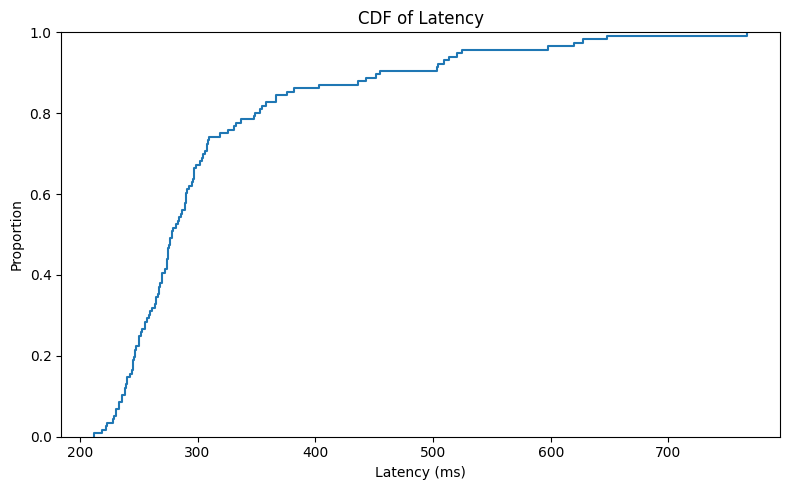

In [9]:
%matplotlib inline

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(f"./npf-out/{now}.csv")

# fig, ax = plt.subplots(figsize=(8, 5))
# sns.lineplot(
#     data=df,
#     x="ADDITIONAL_DATA_SIZE",
#     y="y_LATENCY",
#     markers=True,
#     errorbar="sd",
#     ax=ax,
# )
# ax.set_xlabel("Additional Data Size")
# ax.set_ylabel("Latency (ms)")
# ax.set_title("Latency vs Additional Data Size")
# plt.tight_layout()
# plt.savefig("latency_vs_size.png", dpi=150)
# plt.show()

# plt.figure()
fig, ax = plt.subplots(figsize=(8, 5))
sns.ecdfplot(data=df, x="y_LATENCY", ax=ax)
ax.set_xlabel("Latency (ms)")
ax.set_title("CDF of Latency")
plt.tight_layout()
# plt.savefig("latency_cdf.png", dpi=150)
plt.show()

### Dumping FRRouting config + tunnels

In [ ]:
from pathlib import Path
from datetime import datetime
import subprocess

DUMP_ROOT = Path("./node_config_dumps") / datetime.now().strftime("%Y%m%d_%H%M%S")
DUMP_ROOT.mkdir(parents=True, exist_ok=True)

ROLES_TO_DUMP = ["router"]
COMMANDS = {
    "frr.conf.txt": "sudo cat /etc/frr/frr.conf",
    "frr.daemons.txt": "sudo cat /etc/frr/daemons",
    "ip_addr.txt": "ip -br addr",
    "ip_route.txt": "ip route show",
    "ip_tunnel.txt": "ip tunnel show",
}

def ssh_capture(host, command):
    return subprocess.run(
        ["ssh", f"root@{host}", command],
        capture_output=True,
        text=True,
    )

for role in ROLES_TO_DUMP:
    if role not in roles:
        continue

    role_dir = DUMP_ROOT / role
    role_dir.mkdir(parents=True, exist_ok=True)

    for node in roles[role]:
        host = node.address
        node_name = (getattr(node, "alias", host) or host).replace("/", "_")
        node_dir = role_dir / node_name
        node_dir.mkdir(parents=True, exist_ok=True)

        (node_dir / "node.txt").write_text(
            f"role={role}\nalias={getattr(node, 'alias', '')}\naddress={host}\n",
            encoding="utf-8",
        )

        for output_name, cmd in COMMANDS.items():
            result = ssh_capture(host, cmd)
            out_file = node_dir / output_name

            if result.returncode == 0:
                out_file.write_text(result.stdout, encoding="utf-8")
            else:
                out_file.write_text(
                    "\n".join(
                        [
                            f"Command failed with return code {result.returncode}",
                            f"$ {cmd}",
                            "",
                            "STDERR:",
                            result.stderr,
                            "",
                            "STDOUT:",
                            result.stdout,
                        ]
                    ),
                    encoding="utf-8",
                )

        # make a full copy of /etc/frr as an archive just in case
        frr_archive_path = node_dir / "etc_frr.tar.gz"
        with frr_archive_path.open("wb") as archive_file:
            archive_result = subprocess.run(
                ["ssh", "root","@", host, "sudo tar -C /etc -czf - frr"],
                stdout=archive_file,
                stderr=subprocess.PIPE,
            )

        if archive_result.returncode != 0:
            (node_dir / "etc_frr_archive_error.txt").write_text(
                archive_result.stderr.decode("utf-8", errors="replace"),
                encoding="utf-8",
            )

        print(f"Dumped configs for {host} in {node_dir}")


Dumped configs for parasilo-12.rennes.grid5000.fr into node_config_dumps/20260409_225606/router/parasilo-12.rennes.grid5000.fr
Dumped configs for econome-22.nantes.grid5000.fr into node_config_dumps/20260409_225606/router/econome-22.nantes.grid5000.fr
All node config dumps are available in: /home/corentin/fcquic_applications_master_thesis/evaluations/grid5000/test_gre_tunnels/node_config_dumps/20260409_225606


### Stopping the current booking

In [15]:
provider.destroy()

INFO     [G5k] Reloading 312505 from nantes                              ]8;id=576335;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=643265;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

INFO     [G5k] Reloading 3675476 from rennes                             ]8;id=708876;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=591227;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

INFO     [G5k] Killing the job (nantes, 312505)                          ]8;id=156567;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=241990;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#276\276]8;;\

INFO     [G5k] Job killed (nantes, 312505)                               ]8;id=718491;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=193683;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#257\257]8;;\

INFO     [G5k] Killing the job (rennes, 3675476)                         ]8;id=714832;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=454566;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#276\276]8;;\

INFO     [G5k] Job killed (rennes, 3675476)                              ]8;id=326339;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=841525;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#257\257]8;;\